In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import random
import os
from nilearn.glm.first_level import compute_regressor
from nilearn.glm.first_level import make_first_level_design_matrix, check_design_matrix
from nilearn.plotting import plot_design_matrix

plt.rcParams.update(plt.rcParamsDefault)
#pd.set_option('display.max_rows', None)

In [14]:
# Make output folder
output_dir = os.path.join('..','plots','fMRI','planning')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [15]:
input_dir = os.path.join('..', 'pre-processed', 'data_for_fMRI_modelling')
data = pd.read_csv(os.path.join(input_dir, 'combined_dataframe_binary.csv'), sep= ';')
data = data.sort_values(by=['trial'], ascending=[True])
data = data.reset_index(drop=True)
print(data)

     index  trial  emotional_cue_time response  objectively_correct  subjectively_correct  response_time   RT_s  stimuli_type  iti  ...  stimuli_name  reward_amount subject_id  session  congruency  \
0        0      8        1.720101e+09       up                 True                  True   1.720101e+09  0.447             2    3  ...     Angry_b33           -0.3        902        3           1   
1      312      9        1.720101e+09       up                False                  True   1.720101e+09  0.376             1    2  ...     Happy_b25           -0.2        902        3           1   
2      313     10        1.720101e+09     down                 True                  True   1.720101e+09  0.405             1    2  ...     Happy_b16           -0.1        902        3           1   
3        1     11        1.720101e+09     down                False                  True   1.720101e+09  0.377             2    2  ...      Angry_b3            0.0        902        3           1   


# Vary the ITI

In [16]:
# Now set ITI etc
trial_number =len(data)
median_iti = 7
simulate_iti = True

# Add breaks
break_one = round(trial_number/3)
break_two = round(break_one*2)
print(break_one)
print(break_two)

generated_onset=[0]
for i in range(1, trial_number):
    if i == break_one or i == break_two:
        print(i)
        generated_onset.append(generated_onset[i-1] + random.uniform(median_iti - 1, median_iti + 1) + 60)
    else:
        generated_onset.append(generated_onset[i-1] + random.uniform(median_iti - 1, median_iti + 1))

print(generated_onset)

if simulate_iti is True:
    data['emotional_cue_time'] = data['emotional_cue_time'] - data['emotional_cue_time'][0]
    data['emotional_cue_time_original'] = data['emotional_cue_time']
    data['emotional_cue_time'] = generated_onset
    print(data[['emotional_cue_time','emotional_cue_time_original','valence']])
else:
    data['emotional_cue_time'] = data['emotional_cue_time'] - data['emotional_cue_time'][0]
    print(data[['emotional_cue_time','valence']])
    print(f'average iti ')

200
400
200
400
[0, 7.151060209207385, 14.262288172789834, 20.39934272698907, 27.63055720829486, 35.53442924865075, 42.31642485123071, 49.052971213083865, 55.30413247729873, 61.51421244030367, 68.22705374005517, 75.72811972094834, 82.24106941305308, 89.74882417312512, 96.00715520655753, 103.00513633517485, 109.7160951091429, 116.43968152083556, 122.96095073059774, 130.28050366285274, 138.0573887456462, 145.25550682875723, 152.4868316116429, 159.9749564051267, 167.1322363259378, 175.03695369432393, 181.93163282832086, 188.55471007101954, 194.76292697276165, 202.55145138432707, 210.15288138071045, 217.71685849605333, 224.02210294083022, 230.18565167900945, 236.4942151487723, 243.38936226626527, 250.90223689256695, 257.62985856334575, 265.51032731040675, 272.59446530107095, 279.6691775656196, 286.1915446738545, 293.11614367673025, 299.9829833895103, 306.1825358482868, 312.60220803676214, 319.96487678201095, 326.1718099611758, 333.4312347237085, 340.39414616246034, 347.29226179230767, 353.

# Quickly recode into something the design matrix can use

In [17]:
data['valence'] = data['valence'].replace({0:'angry', 1:'happy'})
data['congruency'] = data['congruency'].replace({0:'incongruent', 1:'congruent'})
data['volatility'] = data['volatility'].replace({0:'stable', 1:'volatile'})
data['onset'] = data['emotional_cue_time']
data['duration'] = 0.1
print(data[['valence','congruency','volatility','onset','duration']])

    valence   congruency volatility        onset  duration
0     angry    congruent     stable     0.000000       0.1
1     happy    congruent     stable     7.151060       0.1
2     happy    congruent     stable    14.262288       0.1
3     angry    congruent     stable    20.399343       0.1
4     angry    congruent     stable    27.630557       0.1
5     happy    congruent     stable    35.534429       0.1
6     happy    congruent     stable    42.316425       0.1
7     angry    congruent     stable    49.052971       0.1
8     angry    congruent     stable    55.304132       0.1
9     angry    congruent     stable    61.514212       0.1
10    happy    congruent     stable    68.227054       0.1
11    happy    congruent     stable    75.728120       0.1
12    happy    congruent     stable    82.241069       0.1
13    angry    congruent     stable    89.748824       0.1
14    angry    congruent     stable    96.007155       0.1
15    happy    congruent     stable   103.005136       0

In [18]:
# Create the new dataframe by transforming the data
restructured_rows = []
for _, row in data.iterrows():
    restructured_rows.append({'trial_type': row['valence'], 'onset': row['onset'], 'duration': row['duration']})
    restructured_rows.append({'trial_type': row['congruency'], 'onset': row['onset'], 'duration': row['duration']})
    restructured_rows.append({'trial_type': row['volatility'], 'onset': row['onset'], 'duration': row['duration']})

# Convert to dataframe
data_design_matrix = pd.DataFrame(restructured_rows)

print(data_design_matrix)

       trial_type        onset  duration
0           angry     0.000000       0.1
1       congruent     0.000000       0.1
2          stable     0.000000       0.1
3           happy     7.151060       0.1
4       congruent     7.151060       0.1
5          stable     7.151060       0.1
6           happy    14.262288       0.1
7       congruent    14.262288       0.1
8          stable    14.262288       0.1
9           angry    20.399343       0.1
10      congruent    20.399343       0.1
11         stable    20.399343       0.1
12          angry    27.630557       0.1
13      congruent    27.630557       0.1
14         stable    27.630557       0.1
15          happy    35.534429       0.1
16      congruent    35.534429       0.1
17         stable    35.534429       0.1
18          happy    42.316425       0.1
19      congruent    42.316425       0.1
20         stable    42.316425       0.1
21          angry    49.052971       0.1
22      congruent    49.052971       0.1
23         stabl

# Scanner info

In [19]:
# Repetition time
tr = 1

# Define scan volumes
time_length = math.ceil(max(data_design_matrix['onset']))
n_volumes = np.linspace(0, time_length, (tr * time_length + 1))
total_volumes = len(n_volumes)

# Design matrix

In [20]:
plot_name = 'Design matrix'
events = pd.DataFrame(
    {"trial_type": data_design_matrix['trial_type'], "onset": data_design_matrix['onset'], "duration": data_design_matrix['duration']}
)
print(events)

       trial_type        onset  duration
0           angry     0.000000       0.1
1       congruent     0.000000       0.1
2          stable     0.000000       0.1
3           happy     7.151060       0.1
4       congruent     7.151060       0.1
5          stable     7.151060       0.1
6           happy    14.262288       0.1
7       congruent    14.262288       0.1
8          stable    14.262288       0.1
9           angry    20.399343       0.1
10      congruent    20.399343       0.1
11         stable    20.399343       0.1
12          angry    27.630557       0.1
13      congruent    27.630557       0.1
14         stable    27.630557       0.1
15          happy    35.534429       0.1
16      congruent    35.534429       0.1
17         stable    35.534429       0.1
18          happy    42.316425       0.1
19      congruent    42.316425       0.1
20         stable    42.316425       0.1
21          angry    49.052971       0.1
22      congruent    49.052971       0.1
23         stabl

In [21]:
design_matrix = make_first_level_design_matrix(
    n_volumes,
    data_design_matrix,
    drift_model = None
)
design_matrix = design_matrix[['angry','happy','congruent','incongruent','stable','volatile','constant']]
print(design_matrix)

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


               angry         happy     congruent   incongruent        stable      volatile  constant
0.0     3.025616e-14  3.044349e-14 -2.369232e-14 -2.314494e-14 -1.024878e-14 -9.832541e-15       1.0
1.0     1.999409e-04 -1.226509e-14  1.999409e-04  1.993347e-14  1.999409e-04 -1.046652e-14       1.0
2.0     3.966518e-03 -9.263426e-15  3.966518e-03  6.575329e-15  3.966518e-03  6.019591e-16       1.0
3.0     1.374693e-02 -9.880657e-16  1.374693e-02 -1.348415e-15  1.374693e-02  6.903669e-16       1.0
4.0     2.371122e-02  1.420710e-14  2.371122e-02  1.976494e-14  2.371122e-02 -3.565395e-14       1.0
5.0     2.787399e-02 -9.418302e-17  2.787399e-02 -5.626896e-16  2.787399e-02 -2.071450e-16       1.0
6.0     2.540001e-02 -2.522969e-16  2.540001e-02 -4.367444e-16  2.540001e-02 -3.128620e-16       1.0
7.0     1.882239e-02 -4.124738e-16  1.882239e-02 -6.230547e-16  1.882239e-02 -3.399525e-16       1.0
8.0     1.112252e-02  8.333634e-05  1.120586e-02 -7.527226e-16  1.120586e-02 -5.628511e-16 

In [22]:
fig, ax = plt.subplots(figsize=(5, 8), nrows=1, ncols=1)
plot_design_matrix(design_matrix, ax=ax)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
fig.show()

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3132/3954100264.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


In [23]:
pd.set_option('display.width', 200)
print(design_matrix.corr())

                angry     happy  congruent  incongruent    stable  volatile  constant
angry        1.000000 -0.806364   0.114593     0.124459  0.146031  0.098947 -0.011721
happy       -0.806364  1.000000   0.131690     0.111042  0.134756  0.114830 -0.060306
congruent    0.114593  0.131690   1.000000    -0.700292  0.183929  0.130323 -0.180034
incongruent  0.124459  0.111042  -0.700292     1.000000  0.165327  0.135686  0.091444
stable       0.146031  0.134756   0.183929     0.165327  1.000000 -0.683117 -0.251778
volatile     0.098947  0.114830   0.130323     0.135686 -0.683117  1.000000  0.170187
constant    -0.011721 -0.060306  -0.180034     0.091444 -0.251778  0.170187  1.000000


# Raw HRF

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3132/4059402365.py:7: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  design_matrix_hrf_plot = design_matrix[:length]


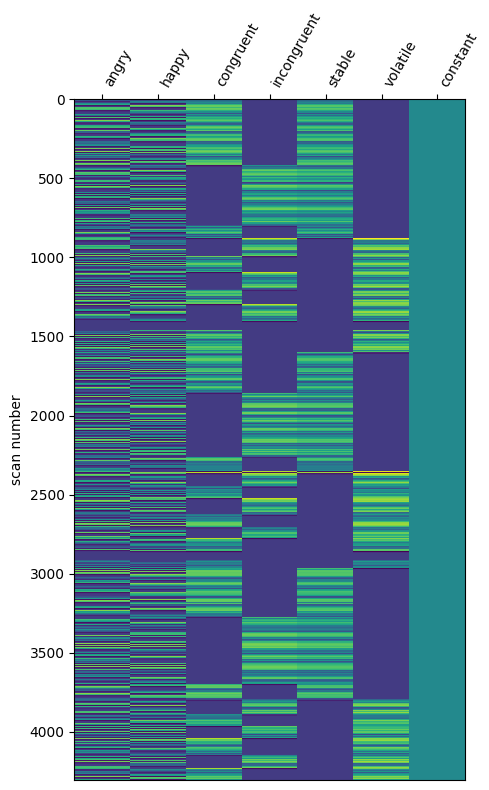

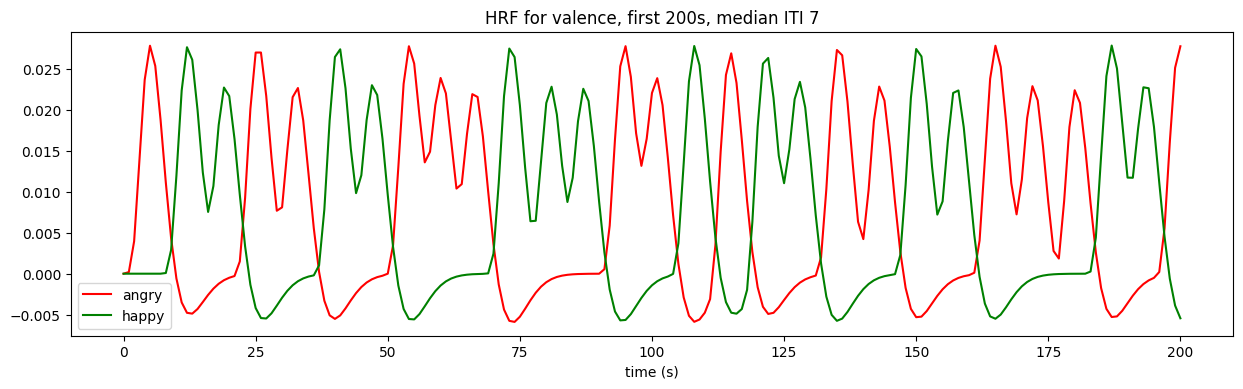

In [24]:
plot_name = f'HRF for valence, first 200s, median ITI {median_iti}'
length = 200

fig = plt.figure(figsize=(15, 4))

n_volumes_selection = n_volumes[:length+1]
design_matrix_hrf_plot = design_matrix[:length]
design_matrix_hrf_plot = design_matrix_hrf_plot.drop(columns=['congruent', 'incongruent', 'stable', 'volatile', 'constant'])

plt.plot(design_matrix_hrf_plot['angry'], label='angry', color='r')
plt.plot(design_matrix_hrf_plot['happy'], label='happy', color='g')
plt.xlabel("time (s)")
plt.legend()
plt.title(plot_name)

# adjust plot
plt.subplots_adjust(bottom=0.12)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()